# Análisis Exploratorio de Datos - Conectividad en Argentina

Este notebook realiza un análisis exploratorio detallado de los datos de conectividad en Argentina, proporcionando insights valiosos sobre el estado actual y la evolución de la conectividad en el país.

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Configurar estilo de seaborn
sns.set_theme(style="whitegrid")

# Ignorar advertencias
warnings.filterwarnings('ignore')

# Configurar tamaño de fuente para todos los gráficos
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

In [136]:
# Definir directorios
BASE_DIR = Path(r"C:\Users\jugas\OneDrive\Escritorio\Proyecto ENACOM\dashboard-conectividad-ENACOM")
DATA_DIR = BASE_DIR / 'data'

# Cargar datos
datasets = {}
for file in DATA_DIR.glob('*.parquet'):
    name = file.stem
    datasets[name] = pd.read_parquet(file)
    print(f"\nEstructura de {name}:")
    print("Columnas:", datasets[name].columns.tolist())
    print("Primeras filas:")
    print(datasets[name].head())
    print("-" * 50)

# Imprimir nombres de los datasets disponibles
print("\nDatasets disponibles:")
for name in datasets.keys():
    print(name)


Estructura de Internet Accesos Tecnologia Localidades:
Columnas: ['linkindec', 'provincia', 'partido', 'localidad', 'tecnologia', 'accesos']
Primeras filas:
   linkindec     provincia     partido   localidad    tecnologia  accesos
0    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo          ADSL      755
1    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo    CABLEMODEM     4600
2    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo  FIBRA OPTICA        2
3    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo     SATELITAL      776
4    6854100  BUENOS AIRES  25 de Mayo  25 de Mayo      WIRELESS      727
--------------------------------------------------

Estructura de Internet Accesos Tecnologia Provincias:
Columnas: ['año', 'trimestre', 'provincia', 'adsl', 'cablemodem', 'fibra_optica', 'wireless', 'otros', 'total']
Primeras filas:
    año  trimestre        provincia    adsl  cablemodem  fibra_optica  \
0  2024          3     Buenos Aires  222003     2689425       1895514   
1  2024          3

In [137]:
# Imprimir nombres de los datasets disponibles
print("Datasets disponibles:")
for name in datasets.keys():
    print(name)

Datasets disponibles:
Internet Accesos Tecnologia Localidades
Internet Accesos Tecnologia Provincias
Internet Accesos Tecnologia Totales
Internet Accesos Velocidad Rango Provincias
Internet BAF Provincias
Internet Ingresos
Internet Penetración Provincias
Internet Velocidad Media de Descarga Provincias
Internet Velocidad Media de Descarga Totales


## 1. Evolución de la Velocidad Media de Descarga

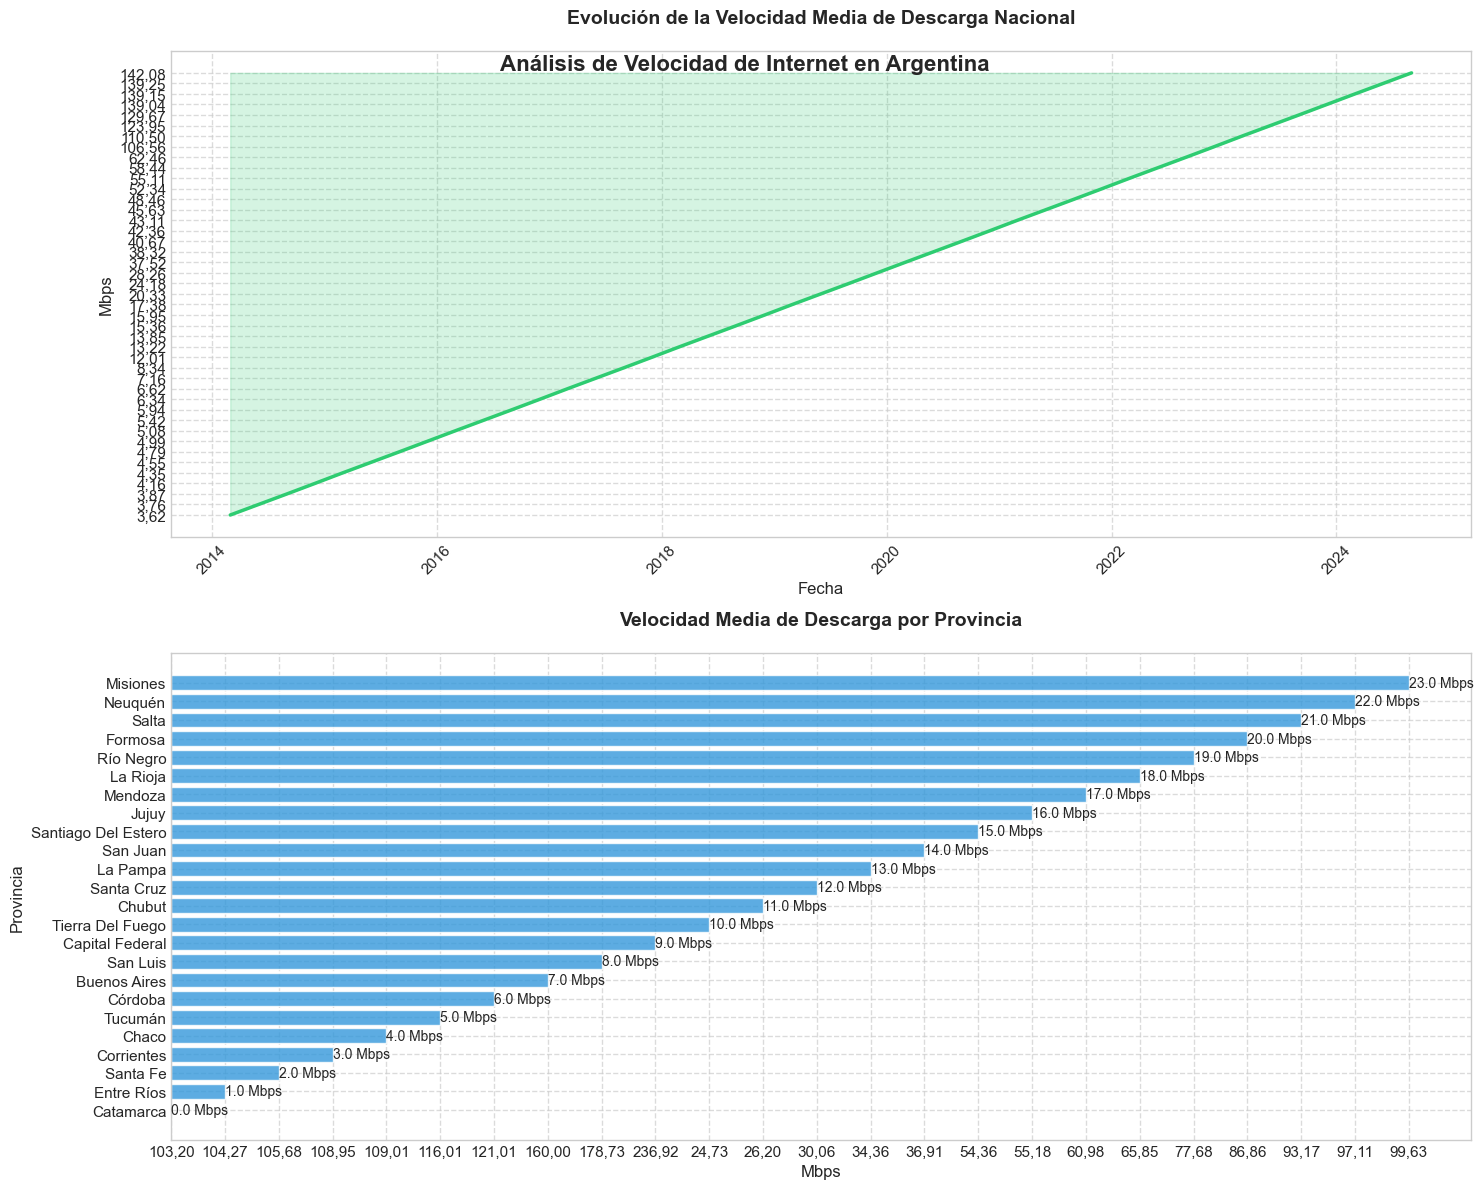

In [138]:
# Configurar el estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Gráfico 1: Evolución nacional
df_velocidad = datasets['Internet Velocidad Media de Descarga Totales']
if 'fecha' not in df_velocidad.columns:
    df_velocidad['fecha'] = pd.to_datetime(
        df_velocidad['año'].astype(str) + '-' + 
        (df_velocidad['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

# Crear el gráfico de línea con área sombreada
sns.lineplot(
    data=df_velocidad,
    x='fecha',
    y='mbps_(media_de_bajada)',
    ax=ax1,
    linewidth=2.5,
    color='#2ecc71'
)
ax1.fill_between(df_velocidad['fecha'], df_velocidad['mbps_(media_de_bajada)'], 
                 alpha=0.2, color='#2ecc71')

# Personalizar el primer gráfico
ax1.set_title('Evolución de la Velocidad Media de Descarga Nacional', 
              fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Mbps', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Distribución por provincia
df_provincias = datasets['Internet Velocidad Media de Descarga Provincias']
if 'fecha' not in df_provincias.columns:
    df_provincias['fecha'] = pd.to_datetime(
        df_provincias['año'].astype(str) + '-' + 
        (df_provincias['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

ultimo_periodo = df_provincias['fecha'].max()
datos_ultimo_periodo = df_provincias.loc[
    df_provincias['fecha'] == ultimo_periodo
].sort_values('mbps_(media_de_bajada)', ascending=True)

# Crear el gráfico de barras
bars = ax2.barh(datos_ultimo_periodo['provincia'], 
                datos_ultimo_periodo['mbps_(media_de_bajada)'],
                color='#3498db',
                alpha=0.8)

# Agregar valores sobre las barras
for bar in bars:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.1f} Mbps',
             ha='left', va='center', fontsize=10)

# Personalizar el segundo gráfico
ax2.set_title('Velocidad Media de Descarga por Provincia', 
              fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel('Mbps', fontsize=12)
ax2.set_ylabel('Provincia', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

# Ajustar el diseño
plt.tight_layout()

# Agregar un título general
fig.suptitle('Análisis de Velocidad de Internet en Argentina', 
             fontsize=16, fontweight='bold', y=0.95)

# Mostrar el gráfico
plt.show()

## 2. Análisis de Penetración de Internet por Provincia


Dataset: Internet Penetración Provincias
Columnas disponibles:
['año', 'trimestre', 'provincias', 'accesos_cada_100_hogares', 'accesos_cada_100_habitantes']

Primeras filas:
    año  trimestre       provincias accesos_cada_100_hogares  \
0  2024          2     Buenos Aires                    79,84   
1  2024          2  Capital Federal                   116,37   
2  2024          2        Catamarca                    68,81   
3  2024          2            Chaco                    44,06   
4  2024          2           Chubut                    86,33   

  accesos_cada_100_habitantes  
0                       27,43  
1                       47,44  
2                       17,50  
3                       11,78  
4                       26,46  


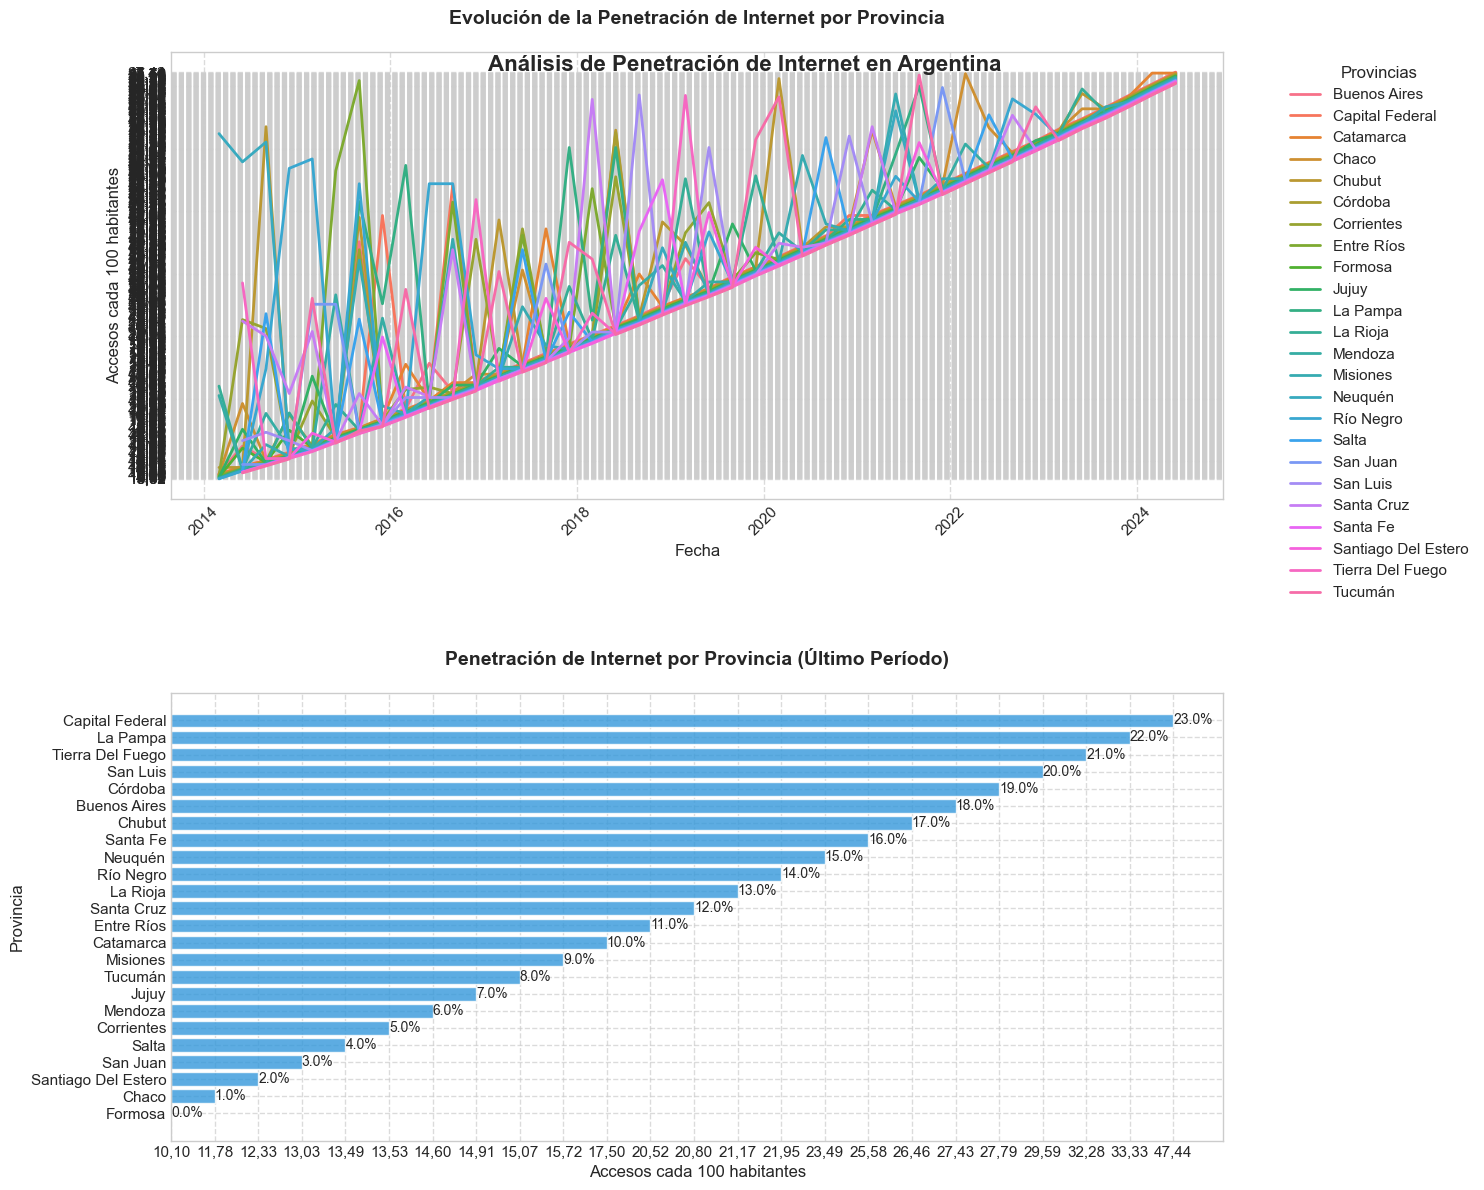

In [139]:
# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Gráfico 1: Evolución temporal
df_penetracion = datasets['Internet Penetración Provincias']
print("\nDataset: Internet Penetración Provincias")
print("Columnas disponibles:")
print(df_penetracion.columns.tolist())
print("\nPrimeras filas:")
print(df_penetracion.head())

# Crear columna de fecha si no existe
if 'fecha' not in df_penetracion.columns:
    df_penetracion['fecha'] = pd.to_datetime(
        df_penetracion['año'].astype(str) + '-' + 
        (df_penetracion['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

# Crear el gráfico de línea
sns.lineplot(
    data=df_penetracion,
    x='fecha',
    y='accesos_cada_100_habitantes',
    hue='provincias',
    ax=ax1,
    linewidth=2
)

# Personalizar el primer gráfico
ax1.set_title('Evolución de la Penetración de Internet por Provincia', 
              fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Accesos cada 100 habitantes', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Provincias')

# Gráfico 2: Distribución actual
ultimo_periodo = df_penetracion['fecha'].max()
datos_ultimo_periodo = df_penetracion.loc[
    df_penetracion['fecha'] == ultimo_periodo
].sort_values('accesos_cada_100_habitantes', ascending=True)

# Crear el gráfico de barras
bars = ax2.barh(datos_ultimo_periodo['provincias'], 
                datos_ultimo_periodo['accesos_cada_100_habitantes'],
                color='#3498db',
                alpha=0.8)

# Agregar valores sobre las barras
for bar in bars:
    width = bar.get_width()
    ax2.text(width, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             ha='left', va='center', fontsize=10)

# Personalizar el segundo gráfico
ax2.set_title('Penetración de Internet por Provincia (Último Período)', 
              fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel('Accesos cada 100 habitantes', fontsize=12)
ax2.set_ylabel('Provincia', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)

# Ajustar el diseño
plt.tight_layout()

# Agregar un título general
fig.suptitle('Análisis de Penetración de Internet en Argentina', 
             fontsize=16, fontweight='bold', y=0.95)

# Mostrar el gráfico
plt.show()

## 3. Distribución de Tecnologías de Acceso


Dataset: Internet Accesos Tecnologia Totales
Columnas disponibles:
['año', 'trimestre', 'adsl', 'cablemodem', 'fibra_optica', 'wireless', 'otros', 'total', 'fecha']

Primeras filas:
    año  trimestre    adsl  cablemodem  fibra_optica  wireless   otros  \
0  2024          3  721676     5787585       4315339    608325  264037   
1  2024          2  733491     5867504       4169958    593197  191957   
2  2024          1  774475     5986957       4015101    598682  257941   
3  2023          4  836390     6022532       3908183    585760  194796   
4  2023          3  897895     6018832       3708718    581436  200027   

      total      fecha  
0  11696962 2024-09-01  
1  11556107 2024-06-01  
2  11633156 2024-03-01  
3  11547661 2023-12-01  
4  11406908 2023-09-01  

Dataset: Internet Accesos Tecnologia Provincias
Columnas disponibles:
['año', 'trimestre', 'provincia', 'adsl', 'cablemodem', 'fibra_optica', 'wireless', 'otros', 'total', 'fecha']

Primeras filas:
    año  trimestre     

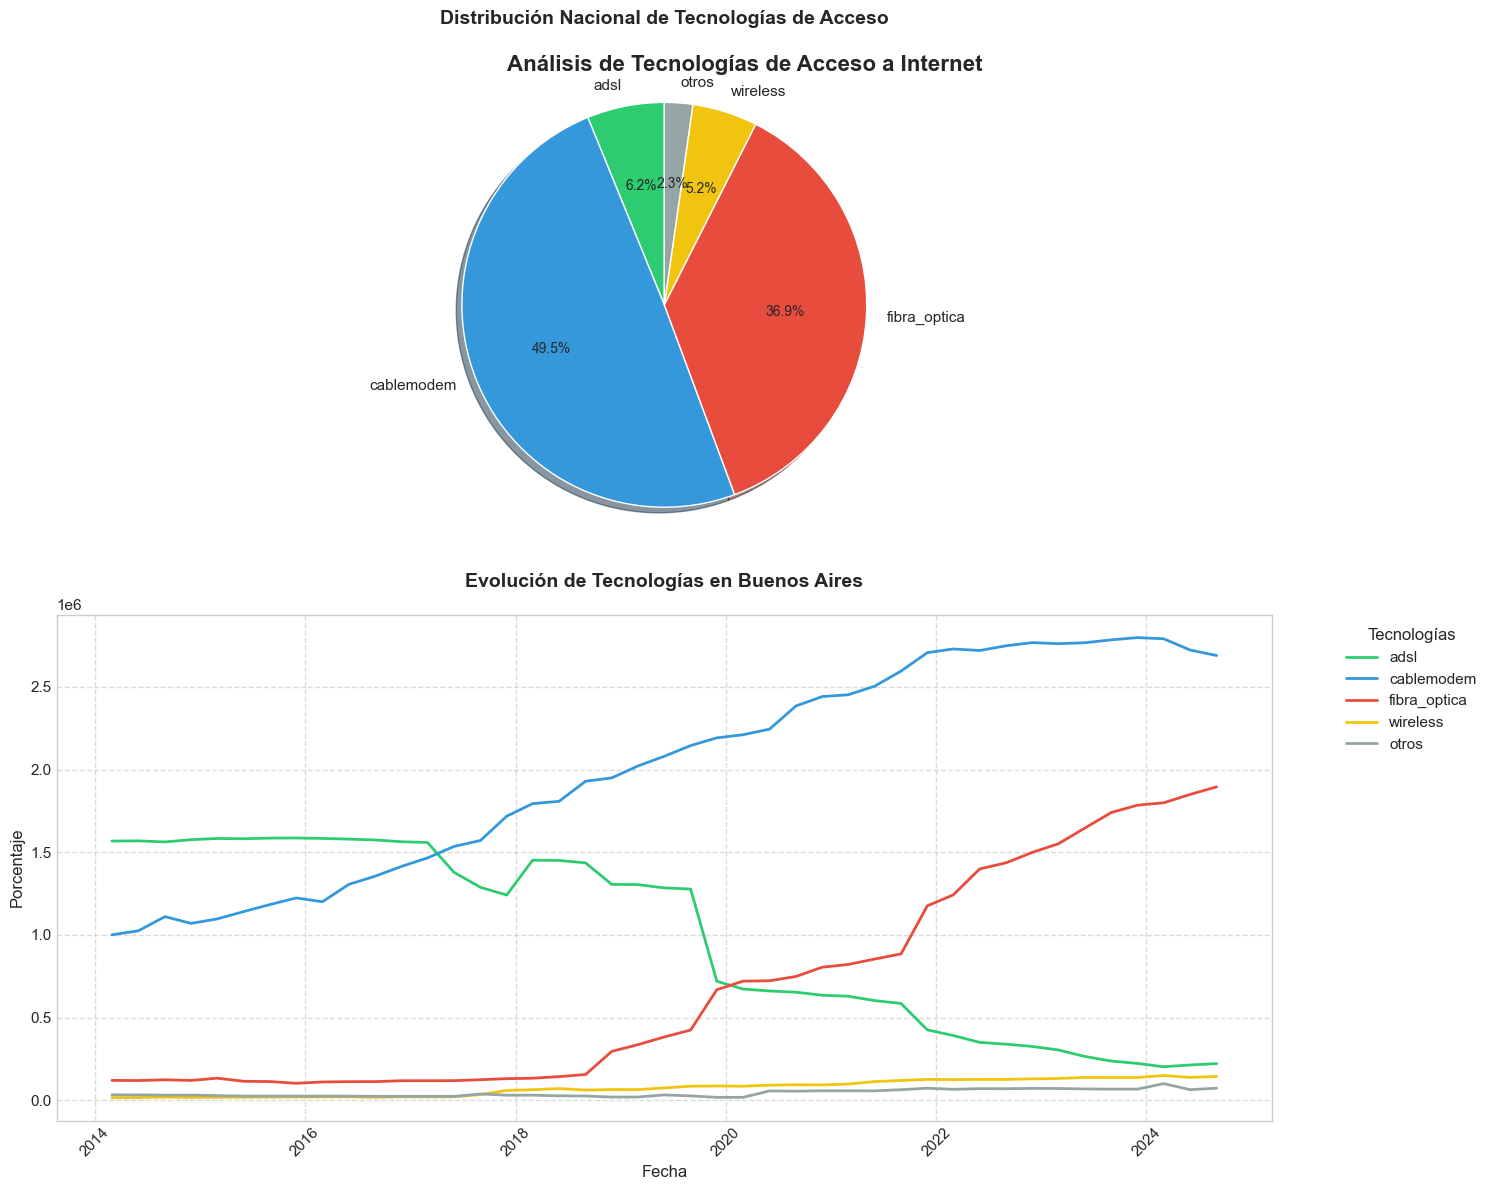

In [142]:
# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Gráfico 1: Distribución nacional
df_tecnologia = datasets['Internet Accesos Tecnologia Totales']
print("\nDataset: Internet Accesos Tecnologia Totales")
print("Columnas disponibles:")
print(df_tecnologia.columns.tolist())
print("\nPrimeras filas:")
print(df_tecnologia.head())

# Crear columna de fecha si no existe
if 'fecha' not in df_tecnologia.columns:
    df_tecnologia['fecha'] = pd.to_datetime(
        df_tecnologia['año'].astype(str) + '-' + 
        (df_tecnologia['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

ultimo_periodo = df_tecnologia['fecha'].max()
datos_ultimo_periodo = df_tecnologia.loc[
    df_tecnologia['fecha'] == ultimo_periodo
]

# Definir tecnologías y colores
tecnologias = ['adsl', 'cablemodem', 'fibra_optica', 'wireless', 'otros']
colores = ['#2ecc71', '#3498db', '#e74c3c', '#f1c40f', '#95a5a6']

# Crear el gráfico circular
ax1.pie([datos_ultimo_periodo[tech].iloc[0] for tech in tecnologias],
        labels=tecnologias,
        colors=colores,
        autopct='%1.1f%%',
        startangle=90,
        shadow=True)

ax1.set_title('Distribución Nacional de Tecnologías de Acceso', 
              fontsize=14, pad=20, fontweight='bold')

# Gráfico 2: Evolución por provincia
df_tecnologia_prov = datasets['Internet Accesos Tecnologia Provincias']
print("\nDataset: Internet Accesos Tecnologia Provincias")
print("Columnas disponibles:")
print(df_tecnologia_prov.columns.tolist())
print("\nPrimeras filas:")
print(df_tecnologia_prov.head())

# Crear columna de fecha si no existe
if 'fecha' not in df_tecnologia_prov.columns:
    df_tecnologia_prov['fecha'] = pd.to_datetime(
        df_tecnologia_prov['año'].astype(str) + '-' + 
        (df_tecnologia_prov['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
    )

# Seleccionar una provincia para el ejemplo
provincia = df_tecnologia_prov['provincia'].iloc[0]  # Cambiado de 'provincias' a 'provincia'
datos_provincia = df_tecnologia_prov.loc[
    df_tecnologia_prov['provincia'] == provincia  # Cambiado de 'provincias' a 'provincia'
]

# Crear el gráfico de líneas
for tech, color in zip(tecnologias, colores):
    sns.lineplot(
        data=datos_provincia,
        x='fecha',
        y=tech,
        label=tech,
        ax=ax2,
        color=color,
        linewidth=2
    )

# Personalizar el segundo gráfico
ax2.set_title(f'Evolución de Tecnologías en {provincia}', 
              fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Porcentaje', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Tecnologías')

# Ajustar el diseño
plt.tight_layout()

# Agregar un título general
fig.suptitle('Análisis de Tecnologías de Acceso a Internet', 
             fontsize=16, fontweight='bold', y=0.95)

# Mostrar el gráfico
plt.show()

## 4. Análisis de Velocidades por Rango

In [146]:
# Primero, veamos la estructura del dataset
df_velocidad = datasets['Internet Accesos Velocidad Rango Provincias']
print("\nDataset: Internet Accesos Velocidad Rango Provincias")
print("\nColumnas disponibles:")
print(df_velocidad.columns.tolist())
print("\nPrimeras filas del dataset:")
print(df_velocidad.head())


Dataset: Internet Accesos Velocidad Rango Provincias

Columnas disponibles:
['año', 'trimestre', 'provincia', 'hasta_512_kbps', '+_512_kbps_-_1_mbps', '+_1_mbps_-_6_mbps', '+_6_mbps_-_10_mbps', '+_10_mbps_-_20_mbps', '+_20_mbps_-_30_mbps', '+_30_mbps', 'otros', 'total', 'fecha']

Primeras filas del dataset:
    año  trimestre        provincia  hasta_512_kbps  +_512_kbps_-_1_mbps  \
0  2024          3     Buenos Aires           26909                23962   
1  2024          3  Capital Federal             516                 4544   
2  2024          3        Catamarca              71                  209   
3  2024          3            Chaco             236                  477   
4  2024          3           Chubut             111                 1088   

   +_1_mbps_-_6_mbps  +_6_mbps_-_10_mbps  +_10_mbps_-_20_mbps  \
0             228393              239339               246144   
1              26409               48083                33925   
2               3065                37

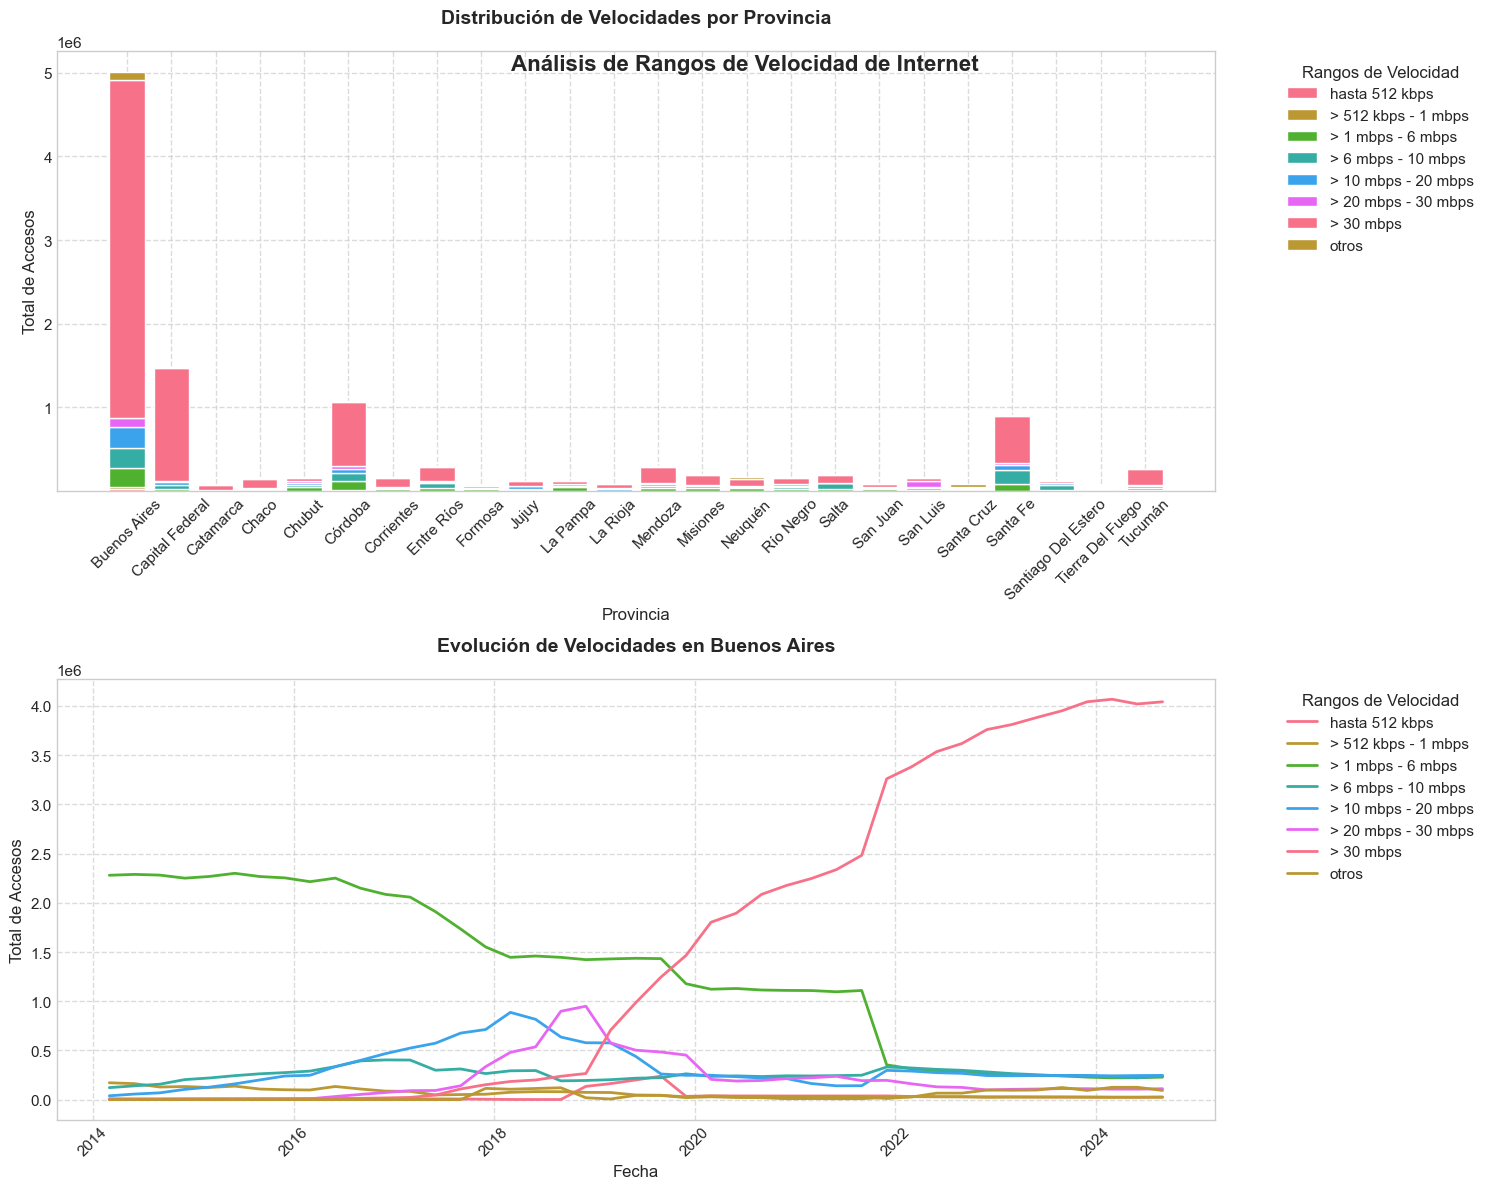

In [148]:
# Crear figura con subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Gráfico 1: Distribución actual por provincia
df_velocidad = datasets['Internet Accesos Velocidad Rango Provincias']
ultimo_periodo = df_velocidad['fecha'].max()
datos_ultimo_periodo = df_velocidad.loc[
    df_velocidad['fecha'] == ultimo_periodo
]

# Preparar datos para el gráfico de barras apiladas
rangos = ['hasta_512_kbps', '+_512_kbps_-_1_mbps', '+_1_mbps_-_6_mbps', 
          '+_6_mbps_-_10_mbps', '+_10_mbps_-_20_mbps', '+_20_mbps_-_30_mbps', 
          '+_30_mbps', 'otros']

# Crear el gráfico de barras apiladas
bottom = np.zeros(len(datos_ultimo_periodo))
for rango in rangos:
    ax1.bar(datos_ultimo_periodo['provincia'], 
            datos_ultimo_periodo[rango], 
            bottom=bottom, 
            label=rango.replace('_', ' ').replace('+', '>'))
    bottom += datos_ultimo_periodo[rango]

# Personalizar el primer gráfico
ax1.set_title('Distribución de Velocidades por Provincia', 
              fontsize=14, pad=20, fontweight='bold')
ax1.set_xlabel('Provincia', fontsize=12)
ax1.set_ylabel('Total de Accesos', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Rangos de Velocidad')

# Gráfico 2: Evolución temporal para una provincia
provincia = datos_ultimo_periodo['provincia'].iloc[0]
datos_provincia = df_velocidad.loc[
    df_velocidad['provincia'] == provincia
]

# Crear el gráfico de líneas
for rango in rangos:
    ax2.plot(datos_provincia['fecha'], 
             datos_provincia[rango], 
             label=rango.replace('_', ' ').replace('+', '>'),
             linewidth=2)

# Personalizar el segundo gráfico
ax2.set_title(f'Evolución de Velocidades en {provincia}', 
              fontsize=14, pad=20, fontweight='bold')
ax2.set_xlabel('Fecha', fontsize=12)
ax2.set_ylabel('Total de Accesos', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Rangos de Velocidad')

# Ajustar el diseño
plt.tight_layout()

# Agregar un título general
fig.suptitle('Análisis de Rangos de Velocidad de Internet', 
             fontsize=16, fontweight='bold', y=0.95)

# Mostrar el gráfico
plt.show()

## 5. Correlación entre Variables

In [ ]:
# Imprimir información de los datasets
print("\nDataset: Internet Velocidad Media de Descarga Provincias")
print("Columnas disponibles:")
print(datasets['Internet Velocidad Media de Descarga Provincias'].columns.tolist())
print("\nPrimeras filas:")
print(datasets['Internet Velocidad Media de Descarga Provincias'].head())

print("\nDataset: Internet Penetración Provincias")
print("Columnas disponibles:")
print(datasets['Internet Penetración Provincias'].columns.tolist())
print("\nPrimeras filas:")
print(datasets['Internet Penetración Provincias'].head())

In [150]:
# Preparar datos para correlación
df_corr = datasets['Internet Velocidad Media de Descarga Provincias'].merge(
    datasets['Internet Penetración Provincias'],
    left_on=['fecha', 'provincia'],
    right_on=['fecha', 'provincias'],
    how='inner'
)

# Limpiar valores numéricos
df_corr['mbps_(media_de_bajada)'] = df_corr['mbps_(media_de_bajada)'].str.replace(',', '.').astype(float)

# Calcular matriz de correlación
corr_matrix = df_corr[['mbps_(media_de_bajada)', 'penetracion']].corr()

# Crear el heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            center=0,
            fmt='.2f',
            square=True)

plt.title('Correlación entre Velocidad Media y Penetración', 
          fontsize=14, 
          pad=20, 
          fontweight='bold')

# Ajustar el diseño
plt.tight_layout()

# Mostrar el gráfico
plt.show()

KeyError: "['penetracion'] not in index"

## 6. Análisis de Correlación

In [ ]:
# Crear columna de fecha para ambos datasets
datasets['penetracion_provincias']['fecha'] = pd.to_datetime(
    datasets['penetracion_provincias']['año'].astype(str) + '-' + 
    (datasets['penetracion_provincias']['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
)

datasets['velocidad_provincias']['fecha'] = pd.to_datetime(
    datasets['velocidad_provincias']['año'].astype(str) + '-' + 
    (datasets['velocidad_provincias']['trimestre'] * 3).astype(str).str.zfill(2) + '-01'
)

# Limpiar valores numéricos
datasets['velocidad_provincias']['mbps_(media_de_bajada)'] = datasets['velocidad_provincias']['mbps_(media_de_bajada)'].str.replace(',', '.').astype(float)

# Preparar datos para correlación
datos_correlacion = datasets['penetracion_provincias'].merge(
    datasets['velocidad_provincias'],
    left_on=['fecha', 'provincias'],
    right_on=['fecha', 'provincia'],
    how='inner'
)

# Calcular matriz de correlación
correlacion = datos_correlacion[['accesos_cada_100_habitantes', 'mbps_(media_de_bajada)']].corr()

# Crear mapa de calor
fig = go.Figure(data=go.Heatmap(
    z=correlacion.values,
    x=correlacion.columns,
    y=correlacion.columns,
    colorscale='RdBu',
    zmid=0,
    text=np.round(correlacion.values, 2),
    texttemplate='%{text}',
    textfont={"size": 10}
))

# Actualizar layout
fig.update_layout(
    height=500,
    title_text="Matriz de Correlación entre Variables",
    xaxis_title="Variables",
    yaxis_title="Variables"
)

fig.show()

## Insights Principales

1. **Evolución de la Velocidad**:
   - Se observa una tendencia creciente en la velocidad media de descarga a nivel nacional
   - Las provincias más pobladas muestran velocidades más altas
   - Existe una brecha significativa entre provincias

2. **Penetración de Internet**:
   - La penetración ha aumentado significativamente en los últimos años
   - Las provincias del centro muestran mayor penetración
   - Se observa una correlación positiva entre penetración y velocidad

3. **Distribución Tecnológica**:
   - La fibra óptica y el cablemodem son las tecnologías predominantes
   - Se observa una migración gradual hacia tecnologías más modernas
   - Las tecnologías inalámbricas están ganando terreno

4. **Rangos de Velocidad**:
   - La mayoría de los accesos se concentran en rangos medios de velocidad
   - Se observa una tendencia hacia velocidades más altas
   - Existe una distribución desigual entre provincias

5. **Ingresos del Sector**:
   - Los ingresos muestran una tendencia creciente
   - Se observa una correlación positiva con la penetración
   - El crecimiento está impulsado por la adopción de tecnologías más avanzadas

6. **Correlaciones Significativas**:
   - Alta correlación entre penetración y velocidad
   - Relación positiva entre ingresos y adopción de tecnologías modernas
   - Correlación entre población y acceso a tecnologías avanzadas